# 02 — Exploratory Data Analysis

**Phase 1: Data Understanding & EDA** · Owner: Ahamed M.A.U (IT24101779) · Group AI-39

Continues from `01_data_understanding.ipynb`. This notebook covers the guide's §5.1 steps 4–6:

- **Part A: target and data quality.** Outcome distribution, missing values, duplicates, validity checks.
- **Part B: patterns.** Home vs away goals, home advantage, team form, draws.

Every non-trivial finding is tagged with **why it matters for modelling** and is copied into `logs/eda_insight_log.md`.

## 1. Setup

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

from src.db import load_matches

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

FIG_DIR = "../outputs/figures"
TABLE_DIR = "../outputs/tables"

# One fixed colour per outcome, used in every chart (colour-blind safe; checked with a palette validator)
OUTCOMES = ["Home Win", "Draw", "Away Win"]
OUTCOME_COLORS = {"Home Win": "#2a78d6", "Draw": "#eb6834", "Away Win": "#1baf7a"}

matches = load_matches().sort_values("date").reset_index(drop=True)
matches.shape

(25979, 119)

# Part A — Target and data quality

## 2. Target variable

The target follows decision D-004: compare full-time goals.

In [2]:
matches["target"] = np.select(
    [matches["home_team_goal"] > matches["away_team_goal"],
     matches["home_team_goal"] == matches["away_team_goal"],
     matches["home_team_goal"] < matches["away_team_goal"]],
    OUTCOMES,
    default="Unknown",   # numpy 2.x needs a string default when the choices are strings
)
assert (matches["target"] != "Unknown").all()

target_dist = pd.DataFrame({
    "matches": matches["target"].value_counts().reindex(OUTCOMES),
    "percent": (matches["target"].value_counts(normalize=True).reindex(OUTCOMES) * 100).round(2),
})
target_dist.loc["Total"] = [target_dist["matches"].sum(), target_dist["percent"].sum().round(2)]
target_dist["matches"] = target_dist["matches"].astype(int)
target_dist

,matches,percent
target,,
Home Win,11917,45.87
Draw,6596,25.39
Away Win,7466,28.74
Total,25979,100.00


In [3]:
# Check against the numbers stated in the Initial Submission
initial_submission = {"Home Win": 11917, "Draw": 6596, "Away Win": 7466}
for outcome, expected in initial_submission.items():
    actual = target_dist.loc[outcome, "matches"]
    assert actual == expected, f"{outcome}: expected {expected}, got {actual}"
print("Initial Submission class counts reproduced exactly from the raw data.")

Initial Submission class counts reproduced exactly from the raw data.


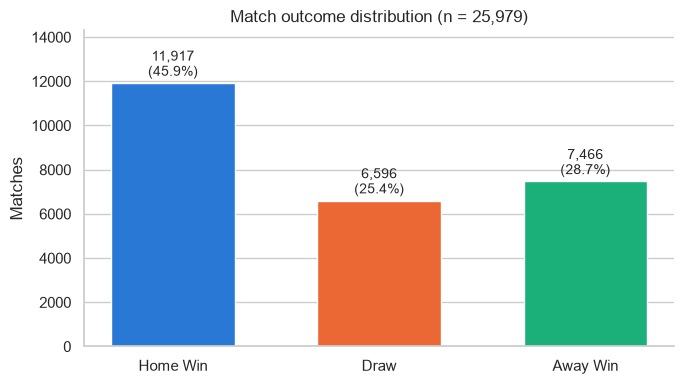

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = target_dist.loc[OUTCOMES, "matches"]
bars = ax.bar(OUTCOMES, counts, color=[OUTCOME_COLORS[o] for o in OUTCOMES], width=0.6)
for bar, (n, pct) in zip(bars, target_dist.loc[OUTCOMES].itertuples(index=False)):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 150, f"{n:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, counts.max() * 1.2)
ax.set_ylabel("Matches")
ax.set_title("Match outcome distribution (n = 25,979)")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_02_target_distribution.png", dpi=150)
plt.show()

**Finding:** the classes are **imbalanced, but not extremely**. Home Win is the most common outcome (45.9%), and **Draw is
the minority class (25.4%)**. A model that always predicts "Home Win" is already right 46% of the time, so accuracy alone
would hide a model that never predicts draws. This supports **macro F1 as the primary metric** (D-008) and
`class_weight="balanced"` as an option for the models.

### 2.1 Majority-class baseline (the floor every model must beat)

In [5]:
y_true = matches["target"]
y_majority = pd.Series("Home Win", index=y_true.index)

baseline = pd.Series({
    "accuracy": accuracy_score(y_true, y_majority),
    "macro_f1": f1_score(y_true, y_majority, average="macro", labels=OUTCOMES, zero_division=0),
}).round(4)
baseline

accuracy    0.4587
macro_f1    0.2096
dtype: float64

Always predicting "Home Win" scores **45.9% accuracy but only 0.21 macro F1**, because it gets 0 recall on Draw and
Away Win. That gap is exactly why D-008 chose macro F1. Yusuf will recompute the baseline on the chronological
**test** set only; this full-data figure is a reference point.

### 2.2 Is the target stable across leagues and seasons?

In [6]:
by_league = pd.crosstab(matches["league_name"], matches["target"], normalize="index")[OUTCOMES]
by_season = pd.crosstab(matches["season"], matches["target"], normalize="index")[OUTCOMES]
(by_league * 100).round(1).sort_values("Home Win", ascending=False)

target,Home Win,Draw,Away Win
league_name,,,
Spain LIGA BBVA,48.8,23.2,28.0
Netherlands Eredivisie,47.8,23.7,28.4
Belgium Jupiler League,46.9,24.6,28.5
Italy Serie A,46.6,26.4,27.0
England Premier League,45.7,25.8,28.5
Switzerland Super League,45.7,24.3,30.0
Poland Ekstraklasa,45.3,27.3,27.3
Germany 1. Bundesliga,45.2,24.4,30.4
France Ligue 1,44.7,28.3,27.0


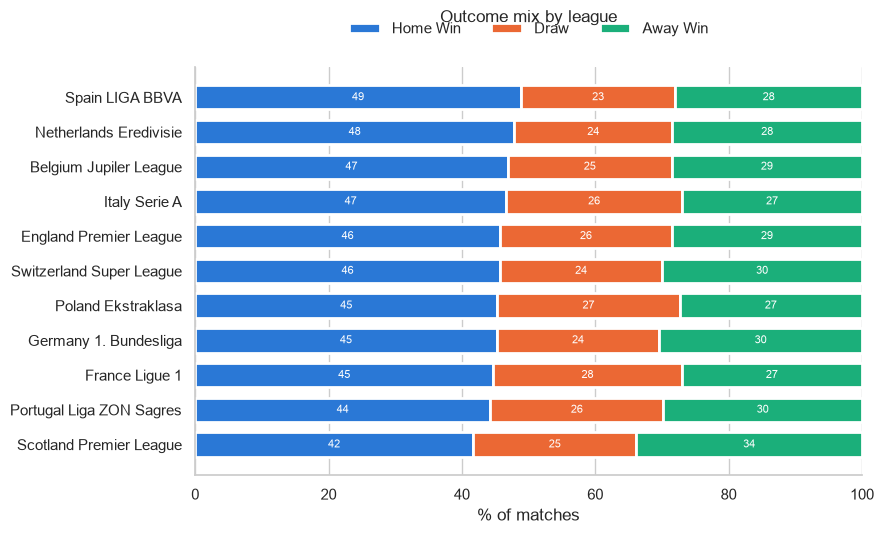

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
order = by_league.sort_values("Home Win").index
left = np.zeros(len(order))
for outcome in OUTCOMES:
    vals = by_league.loc[order, outcome].values * 100
    ax.barh(order, vals, left=left, color=OUTCOME_COLORS[outcome], label=outcome,
            edgecolor="white", linewidth=2, height=0.7)
    for y, (l, v) in enumerate(zip(left, vals)):
        ax.text(l + v / 2, y, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white")
    left += vals
ax.set_xlim(0, 100)
ax.set_xlabel("% of matches")
ax.set_title("Outcome mix by league", pad=32)
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.04), frameon=False)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_03_target_by_league.png", dpi=150)
plt.show()

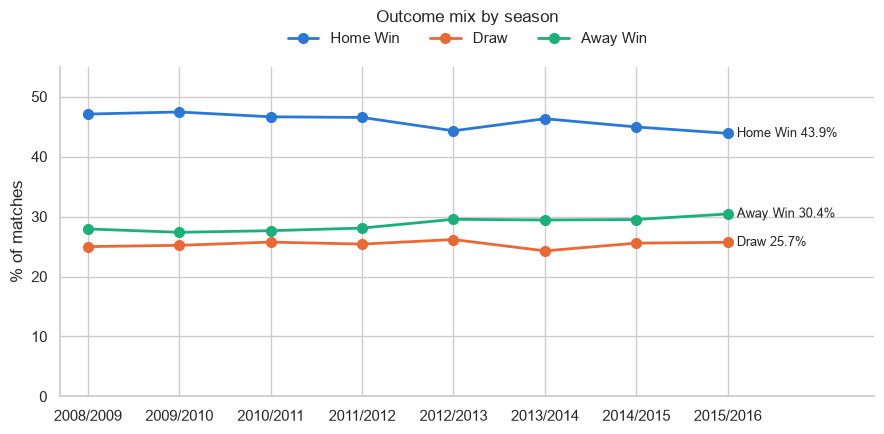

target,Home Win,Draw,Away Win
season,,,
2008/2009,47.1,25.0,27.9
2009/2010,47.4,25.2,27.4
2010/2011,46.6,25.7,27.6
2011/2012,46.5,25.4,28.1
2012/2013,44.3,26.2,29.5
2013/2014,46.3,24.3,29.4
2014/2015,44.9,25.6,29.5
2015/2016,43.9,25.7,30.4


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for outcome in OUTCOMES:
    s = by_season[outcome] * 100
    ax.plot(s.index, s.values, marker="o", markersize=7, linewidth=2, color=OUTCOME_COLORS[outcome], label=outcome)
    ax.text(len(s) - 1 + 0.1, s.iloc[-1], f"{outcome} {s.iloc[-1]:.1f}%", va="center", fontsize=9)
ax.set_ylim(0, 55)
ax.set_xlim(-0.3, len(by_season) + 0.6)
ax.set_ylabel("% of matches")
ax.set_title("Outcome mix by season", pad=32)
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_04_target_by_season.png", dpi=150)
plt.show()
(by_season * 100).round(1)

**Findings:**

- **Across leagues** the home-win rate ranges from **41.7% (Scotland)** to **48.8% (Spain)**. The draw rate ranges from
  **23.2% (Spain)** to **28.3% (France)**. The leagues differ, but not dramatically, so one model across all leagues is
  reasonable. League could still be a useful context feature.
- **Across seasons** the home-win rate **drifts down** from 47.1% (2008/09) to 43.9% (2015/16), while away wins rise from
  27.9% to 30.4%. Draws stay flat at about 25%.
- **Why it matters:** with a chronological split (D-009), the **test seasons have fewer home wins than training**.
  A model that over-relies on "home team wins" will be slightly worse on the test set than in training. The
  majority-baseline accuracy on the test set will also be below the 45.9% seen on the full data. Yusuf should report the
  class distribution of train vs test (guide §5.5 step 3).

## 3. Missing values

`01_data_understanding.ipynb` showed the average missingness per column group. Here we check **where** the gaps are,
because values missing at random and values missing for whole leagues have to be handled differently.

In [9]:
raw_cols = list(load_matches(with_names=False).columns)          # the 115 original columns
missing = matches[raw_cols].isna().mean().mul(100).round(1)
print(f"{(missing > 0).sum()} of {len(raw_cols)} raw columns have missing values.")
print("Complete columns:", ", ".join(missing[missing == 0].index))

# Columns with the same % missing belong to the same source, so group them
(missing[missing > 0].groupby(missing).apply(lambda s: f"{len(s)} cols, e.g. {', '.join(s.index[:3])}")
 .sort_index(ascending=False).to_frame("columns"))

104 of 115 raw columns have missing values.
Complete columns: id, country_id, league_id, season, stage, date, match_api_id, home_team_api_id, away_team_api_id, home_team_goal, away_team_goal


,columns
57.0,"3 cols, e.g. PSH, PSD, PSA"
45.5,"6 cols, e.g. GBH, GBD, GBA"
45.3,"8 cols, e.g. goal, shoton, shotoff"
34.2,"3 cols, e.g. SJH, SJD, SJA"
13.3,"3 cols, e.g. IWH, IWD, IWA"
13.2,"3 cols, e.g. LBH, LBD, LBA"
13.1,"9 cols, e.g. BWH, BWD, BWA"
13.0,"3 cols, e.g. B365H, B365D, B365A"
7.1,"40 cols, e.g. home_player_X3, home_player_X4, ..."
7.0,"4 cols, e.g. home_player_X1, home_player_X2, h..."


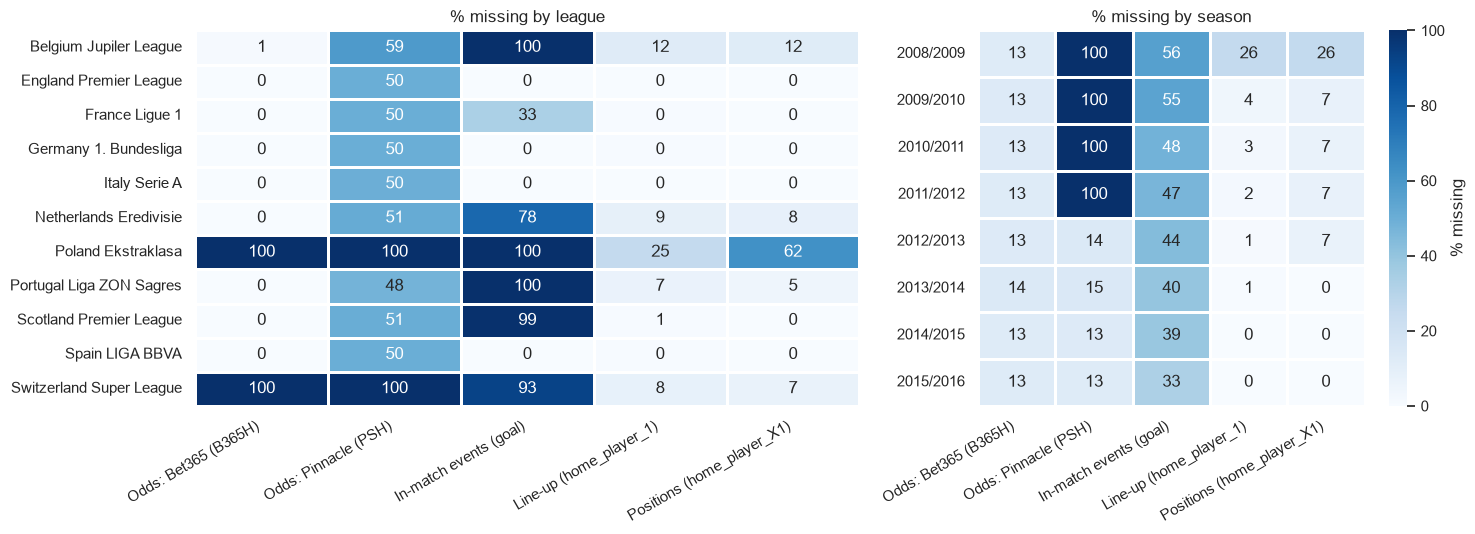

In [10]:
# One representative column per group, so the pattern is readable
group_cols = {
    "Odds: Bet365 (B365H)": "B365H",
    "Odds: Pinnacle (PSH)": "PSH",
    "In-match events (goal)": "goal",
    "Line-up (home_player_1)": "home_player_1",
    "Positions (home_player_X1)": "home_player_X1",
}
miss_league = matches.groupby("league_name")[list(group_cols.values())].apply(lambda d: d.isna().mean() * 100)
miss_season = matches.groupby("season")[list(group_cols.values())].apply(lambda d: d.isna().mean() * 100)
miss_league.columns = miss_season.columns = list(group_cols.keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [11, 8]})
for ax, data, title in [(axes[0], miss_league, "by league"), (axes[1], miss_season, "by season")]:
    sns.heatmap(data, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100, cbar=ax is axes[1],
                cbar_kws={"label": "% missing"}, linewidths=1, linecolor="white", ax=ax)
    ax.set_title(f"% missing {title}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
    plt.setp(ax.get_xticklabels(), ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_05_missing_by_league_season.png", dpi=150)
plt.show()

In [11]:
miss_league.round(1)

,Odds: Bet365 (B365H),Odds: Pinnacle (PSH),In-match events (goal),Line-up (home_player_1),Positions (home_player_X1)
league_name,,,,,
Belgium Jupiler League,1.3,58.9,100.0,12.4,12.0
England Premier League,0.0,50.0,0.0,0.0,0.0
France Ligue 1,0.1,50.0,33.4,0.4,0.0
Germany 1. Bundesliga,0.0,50.0,0.0,0.5,0.0
Italy Serie A,0.2,49.8,0.1,0.0,0.0
Netherlands Eredivisie,0.1,51.2,78.3,8.7,8.4
Poland Ekstraklasa,100.0,100.0,99.6,25.4,62.5
Portugal Liga ZON Sagres,0.4,47.7,100.0,6.9,5.1
Scotland Premier League,0.0,50.8,99.3,0.7,0.0


In [12]:
miss_season.round(1)

,Odds: Bet365 (B365H),Odds: Pinnacle (PSH),In-match events (goal),Line-up (home_player_1),Positions (home_player_X1)
season,,,,,
2008/2009,12.9,100.0,56.4,25.6,25.9
2009/2010,13.1,100.0,55.0,4.2,7.4
2010/2011,13.0,100.0,48.3,3.0,7.4
2011/2012,12.6,100.0,46.8,2.1,7.5
2012/2013,13.1,14.4,44.0,1.2,7.4
2013/2014,14.3,14.6,39.8,0.6,0.0
2014/2015,12.7,13.1,38.9,0.1,0.0
2015/2016,12.7,12.9,32.9,0.2,0.0


**Findings:** the missingness is **structural, not random**. It depends on the league and the season:

| Column group | Pattern | Why it matters / action |
|---|---|---|
| **Goals, teams, date, season, stage** | **0% missing** | Target and every history feature can be computed for all 25,979 matches. No imputation needed for the core pipeline. |
| **Odds (Bet365 etc.)** | ~13% overall, but **100% missing for Poland and Switzerland**, ~0% elsewhere | Excluded as features (D-011). Mean imputation would invent odds for two entire leagues. |
| **Odds (Pinnacle)** | 100% missing before 2012/13 | Same: not usable. |
| **In-match events** | **Only complete for England, Germany, Italy and Spain**; 100% missing for Belgium and Portugal | Leakage anyway (D-010). Even if not, using them would silently restrict the model to 4 leagues. |
| **Line-ups / positions** | 26% missing in 2008/09, < 8% after; worst in Poland (25% line-ups, 62% positions) | Out of scope (team-level lens). |

**Key consequence for Umair:** after dropping the excluded groups, the modelling table has **no missing raw values**.
Missing values will only appear in **engineered** features, for example a team's first matches with no "last 5" history
yet (cold start), and in Team_Attributes before 2010-02-22. Those need their own handling, analysed in Part B.

## 4. Duplicates

In [13]:
key = ["date", "home_team_api_id", "away_team_api_id"]
team_day = pd.concat([
    matches[["date", "home_team_api_id"]].rename(columns={"home_team_api_id": "team"}),
    matches[["date", "away_team_api_id"]].rename(columns={"away_team_api_id": "team"}),
])
dup_checks = pd.Series({
    "Fully identical rows (excluding id)": matches.drop(columns=["id"]).duplicated().sum(),
    "Duplicate match_api_id": matches["match_api_id"].duplicated().sum(),
    "Same date + home + away team": matches.duplicated(key).sum(),
    "Team playing twice on the same day": team_day.duplicated().sum(),
    "Same season + home + away team (repeat fixture)": matches.duplicated(["season", "home_team_api_id", "away_team_api_id"]).sum(),
})
dup_checks.to_frame("count")

,count
Fully identical rows (excluding id),0
Duplicate match_api_id,0
Same date + home + away team,0
Team playing twice on the same day,0
Same season + home + away team (repeat fixture),1470


In [14]:
repeat = matches[matches.duplicated(["season", "home_team_api_id", "away_team_api_id"], keep=False)]
repeat["league_name"].value_counts().rename("rows involved in a repeated fixture")

league_name
Scotland Premier League     1502
Switzerland Super League    1404
Name: rows involved in a repeated fixture, dtype: int64

**Findings:**

- **No true duplicates.** No identical rows, no repeated `match_api_id`, and no fixture recorded twice on the same date.
- **No team plays twice on the same day.** The date has no kickoff time, but **ordering by date alone is enough** to know
  which of a team's matches came first. "Strictly earlier matches" (guide §5.3) is unambiguous.
- The repeat home fixtures within a season are **only in Scotland and Switzerland**, whose formats have teams meet 3–4
  times a season. These are real, separate matches, **not duplicates**. **Do not de-duplicate on (season, home, away).**

## 5. Validity checks

In [15]:
validity = pd.Series({
    "Null home/away goals": matches[["home_team_goal", "away_team_goal"]].isna().any(axis=1).sum(),
    "Negative goals": (matches[["home_team_goal", "away_team_goal"]] < 0).any(axis=1).sum(),
    "Team plays itself": (matches["home_team_api_id"] == matches["away_team_api_id"]).sum(),
    "Date outside its season (Jul–Jun)": (~matches.apply(
        lambda r: pd.Timestamp(f"{r['season'][:4]}-07-01") <= r["date"] < pd.Timestamp(f"{r['season'][5:]}-07-01"),
        axis=1)).sum(),
    "Missing team name after join": matches[["home_team_name", "away_team_name"]].isna().any(axis=1).sum(),
})
validity.to_frame("count")

,count
Null home/away goals,0
Negative goals,0
Team plays itself,0
Date outside its season (Jul–Jun),0
Missing team name after join,0


In [16]:
matches["total_goals"] = matches["home_team_goal"] + matches["away_team_goal"]
print("Goals per side: home 0–%d, away 0–%d" % (matches["home_team_goal"].max(), matches["away_team_goal"].max()))
print("Matches with 10+ total goals:", (matches["total_goals"] >= 10).sum())
matches.loc[matches["total_goals"] >= 10,
            ["date", "league_name", "home_team_name", "away_team_name", "home_team_goal", "away_team_goal"]]

Goals per side: home 0–10, away 0–9
Matches with 10+ total goals: 14


,date,league_name,home_team_name,away_team_name,home_team_goal,away_team_goal
4426,2009-11-08,France Ligue 1,Olympique Lyonnais,Olympique de Marseille,5,5
4499,2009-11-22,England Premier League,Tottenham Hotspur,Wigan Athletic,9,1
6424,2010-05-05,Scotland Premier League,Motherwell,Hibernian,6,6
7392,2010-10-24,Netherlands Eredivisie,PSV,Feyenoord,10,0
10110,2011-08-28,England Premier League,Manchester United,Arsenal,8,2
10908,2011-11-06,Netherlands Eredivisie,FC Utrecht,Ajax,6,4
14689,2012-12-29,England Premier League,Arsenal,Newcastle United,7,3
15567,2013-03-30,Germany 1. Bundesliga,FC Bayern Munich,Hamburger SV,9,2
16187,2013-05-19,England Premier League,West Bromwich Albion,Manchester United,5,5
17175,2013-10-30,Spain LIGA BBVA,Real Madrid CF,Sevilla FC,7,3


**Findings:**

- All checks return **0**. There are no null or negative goals, no team plays itself, every date falls inside its season,
  and every team ID resolves to a name.
- The most extreme scores (e.g. **PSV 10–0 Feyenoord**, 2010; **Real Madrid 10–2 Rayo Vallecano**, 2015;
  **Deportivo 2–8 Real Madrid**, 2014) are **real, well-known results**, not entry errors. They are **kept**: removing
  genuine thrashings would distort the rolling goal averages of the teams involved. Their effect on a 5-match average is
  temporary, and scaling (or tree models) handles the range.

## 6. Data-quality summary (Part A)

| # | Finding | Why it matters for modelling | Action / owner |
|---|---|---|---|
| A1 | Class split reproduces the Initial Submission exactly (45.87 / 25.39 / 28.74) | Confirms target logic and dataset version | None |
| A2 | Draw is the minority (25.4%); majority baseline = 45.9% accuracy but 0.21 macro F1 | Accuracy misleads; use macro F1 (D-008), consider `class_weight="balanced"` | Yusuf |
| A3 | Home-win rate falls from 47.1% (2008/09) to 43.9% (2015/16) | The chronological test set has fewer home wins than training; report train/test class balance | Yusuf |
| A4 | Home-win rate varies by league (41.7% Scotland – 48.8% Spain) | League is a candidate context feature | Umair |
| A5 | Core columns (goals, teams, date) are 100% complete | No imputation needed for raw inputs | Umair |
| A6 | Odds missing for whole leagues (Poland, Switzerland), events only complete for 4 leagues | Structural missingness; imputing would fabricate data. Confirms exclusion (D-010, D-011) | Umair |
| A7 | No duplicates; no team plays twice on one day | Date ordering is enough for strictly-earlier history features | Umair |
| A8 | Repeated (season, home, away) fixtures in Scotland/Switzerland are real | Do not de-duplicate on that key | Umair |
| A9 | Extreme scores (up to 10–0) are genuine | Keep them; no outlier removal on goals | Umair |

# Part B — Patterns

These are the patterns behind the supporting lens (**Team Form & Home Advantage**, D-003). Each subsection checks
whether a planned feature carries real signal before Umair builds it properly.

## 7. Home vs away goals

Mean goals: home 1.54, away 1.16, difference 0.38 per match


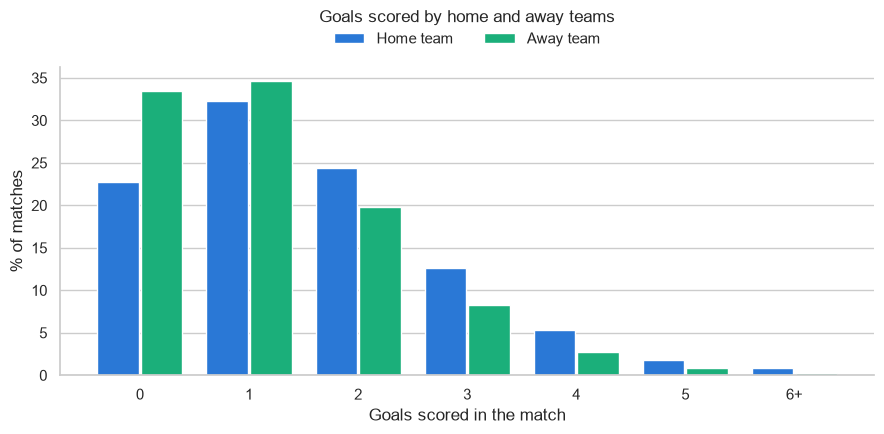

,0,1,2,3,4,5,6+
Home team,22.7,32.3,24.4,12.7,5.3,1.8,0.8
Away team,33.4,34.6,19.8,8.3,2.8,0.8,0.3


In [17]:
goals = pd.DataFrame({
    "Home team": matches["home_team_goal"].clip(upper=6).value_counts(normalize=True).sort_index() * 100,
    "Away team": matches["away_team_goal"].clip(upper=6).value_counts(normalize=True).sort_index() * 100,
})
goals.index = [str(i) if i < 6 else "6+" for i in goals.index]

print(f"Mean goals: home {matches['home_team_goal'].mean():.2f}, away {matches['away_team_goal'].mean():.2f}, "
      f"difference {(matches['home_team_goal'] - matches['away_team_goal']).mean():.2f} per match")

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(goals))
w = 0.38
for i, (col, color) in enumerate([("Home team", OUTCOME_COLORS["Home Win"]), ("Away team", OUTCOME_COLORS["Away Win"])]):
    ax.bar(x + (i - 0.5) * (w + 0.02), goals[col], width=w, color=color, label=col)
ax.set_xticks(x, goals.index)
ax.set_xlabel("Goals scored in the match")
ax.set_ylabel("% of matches")
ax.set_title("Goals scored by home and away teams", pad=32)
ax.legend(ncol=2, loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_06_goals_home_vs_away.png", dpi=150)
plt.show()
goals.round(1).T

In [18]:
matches.groupby("season")[["home_team_goal", "away_team_goal", "total_goals"]].mean().round(2)

,home_team_goal,away_team_goal,total_goals
season,,,
2008/2009,1.51,1.10,2.61
2009/2010,1.54,1.13,2.67
2010/2011,1.55,1.14,2.68
2011/2012,1.57,1.14,2.72
2012/2013,1.55,1.22,2.77
2013/2014,1.58,1.19,2.77
2014/2015,1.52,1.16,2.68
2015/2016,1.54,1.21,2.75


**Findings:**

- Home teams score **1.54** goals per match and away teams **1.16**, a home edge of **0.38 goals per match**. Away teams
  fail to score in **33%** of matches; home teams in only **23%**.
- Goals per match are stable at about 2.6–2.8 across seasons. Away goals rise slightly (1.10 → 1.21), which matches
  the rise in away wins seen in Section 2.2.
- **Why it matters:** the venue alone shifts the goal distribution, so goals-scored and goals-conceded features should
  be read **together with venue**. That supports separate home and away win-rate features (`Home_Win_Rate`, `Away_Win_Rate`).

## 8. Home advantage by league

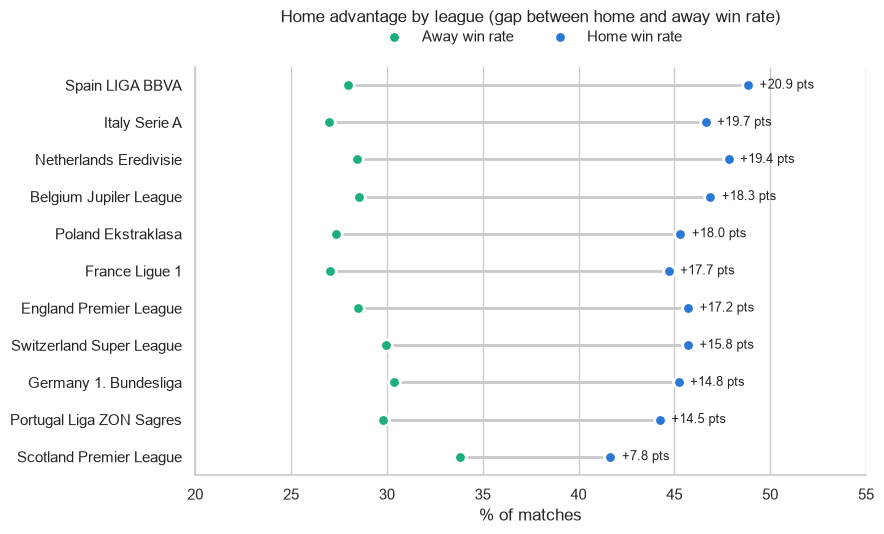

,home_win_rate,away_win_rate,home_goals,away_goals,home_advantage_pts
league_name,,,,,
Scotland Premier League,41.67,33.83,1.43,1.20,7.84
Portugal Liga ZON Sagres,44.25,29.78,1.41,1.13,14.47
Germany 1. Bundesliga,45.22,30.39,1.63,1.27,14.83
Switzerland Super League,45.71,29.96,1.66,1.27,15.75
England Premier League,45.72,28.52,1.55,1.16,17.20
France Ligue 1,44.70,27.04,1.40,1.04,17.66
Poland Ekstraklasa,45.31,27.34,1.39,1.03,17.97
Belgium Jupiler League,46.88,28.53,1.61,1.19,18.34
Netherlands Eredivisie,47.83,28.43,1.78,1.30,19.40


In [19]:
league_adv = matches.groupby("league_name").agg(
    home_win_rate=("target", lambda s: (s == "Home Win").mean() * 100),
    away_win_rate=("target", lambda s: (s == "Away Win").mean() * 100),
    home_goals=("home_team_goal", "mean"),
    away_goals=("away_team_goal", "mean"),
)
league_adv["home_advantage_pts"] = league_adv["home_win_rate"] - league_adv["away_win_rate"]
league_adv = league_adv.sort_values("home_advantage_pts")

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(league_adv))
ax.hlines(y, league_adv["away_win_rate"], league_adv["home_win_rate"], color="#c9c9c9", linewidth=2)
ax.scatter(league_adv["away_win_rate"], y, s=70, color=OUTCOME_COLORS["Away Win"], label="Away win rate", zorder=3,
           edgecolor="white", linewidth=2)
ax.scatter(league_adv["home_win_rate"], y, s=70, color=OUTCOME_COLORS["Home Win"], label="Home win rate", zorder=3,
           edgecolor="white", linewidth=2)
for yi, (_, r) in zip(y, league_adv.iterrows()):
    ax.text(r["home_win_rate"] + 0.6, yi, f"+{r['home_advantage_pts']:.1f} pts", va="center", fontsize=9)
ax.set_yticks(y, league_adv.index)
ax.set_xlim(20, 55)
ax.set_xlabel("% of matches")
ax.set_title("Home advantage by league (gap between home and away win rate)", pad=32)
ax.legend(ncol=2, loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_07_home_advantage_by_league.png", dpi=150)
plt.show()
league_adv.round(2)

**Findings:**

- **Every league has a home advantage.** The home-win rate beats the away-win rate by **+7.8 points (Scotland)** to
  **+20.9 points (Spain)**.
- Scotland is the clear outlier: its smallest home edge (41.7% vs 33.8%) fits a small league where teams meet up to four
  times a season, so travel and familiarity matter less.
- **Why it matters:** home advantage is real but **not uniform**. A single global "home bonus" would under-fit Spain and
  over-fit Scotland. Team-level home/away win rates capture this automatically, because they are computed within each
  team's own league.

## 9. Team-level home and away performance

To measure each team's home and away strength we need **one row per team per match** (the long format from guide §5.3).

In [20]:
def team_long(df):
    """Two rows per match, one per team, from that team's point of view."""
    cols = ["id", "date", "season", "league_name"]
    home = df[cols + ["home_team_api_id", "home_team_goal", "away_team_goal"]].rename(
        columns={"home_team_api_id": "team_api_id", "home_team_goal": "goals_for", "away_team_goal": "goals_against"})
    away = df[cols + ["away_team_api_id", "away_team_goal", "home_team_goal"]].rename(
        columns={"away_team_api_id": "team_api_id", "away_team_goal": "goals_for", "home_team_goal": "goals_against"})
    home["venue"], away["venue"] = "home", "away"
    long = pd.concat([home, away]).sort_values(["team_api_id", "date"]).reset_index(drop=True)
    long["points"] = np.select([long["goals_for"] > long["goals_against"],
                                long["goals_for"] == long["goals_against"]], [3, 1], default=0)
    long["win"] = (long["goals_for"] > long["goals_against"]).astype(int)
    return long

team_matches = team_long(matches)
print(team_matches.shape, "= 2 ×", len(matches), "matches")
team_matches.head()

(51958, 10) = 2 × 25979 matches


,id,date,season,league_name,team_api_id,goals_for,goals_against,venue,points,win
0,15723,2008-08-10,2008/2009,Poland Ekstraklasa,1601,0,0,away,1,0
1,15810,2008-08-16,2008/2009,Poland Ekstraklasa,1601,2,1,home,3,1
2,15898,2008-08-22,2008/2009,Poland Ekstraklasa,1601,2,1,home,3,1
3,15916,2008-08-30,2008/2009,Poland Ekstraklasa,1601,0,3,away,0,0
4,15922,2008-09-12,2008/2009,Poland Ekstraklasa,1601,2,0,home,3,1


In [21]:
MIN_MATCHES = 60   # about two seasons, so rates are not driven by a handful of games
n_matches = team_matches.groupby("team_api_id").size()
team_rates = team_matches.groupby(["team_api_id", "venue"])["win"].mean().unstack() * 100
team_rates = team_rates[n_matches.reindex(team_rates.index) >= MIN_MATCHES]

print(f"Teams with >= {MIN_MATCHES} matches: {len(team_rates)} of {team_matches['team_api_id'].nunique()}")
print(f"Teams that win more often at home than away: {(team_rates['home'] > team_rates['away']).mean():.1%}")
print(f"Correlation between a team's home and away win rate: {team_rates['home'].corr(team_rates['away']):.2f}")
team_rates.describe().round(1)

Teams with >= 60 matches: 247 of 299
Teams that win more often at home than away: 97.2%
Correlation between a team's home and away win rate: 0.83


venue,away,home
count,247.0,247.0
mean,26.7,43.3
std,12.2,13.8
min,7.8,18.4
25%,18.4,33.9
50%,24.6,40.4
75%,31.6,50.2
max,68.4,86.2


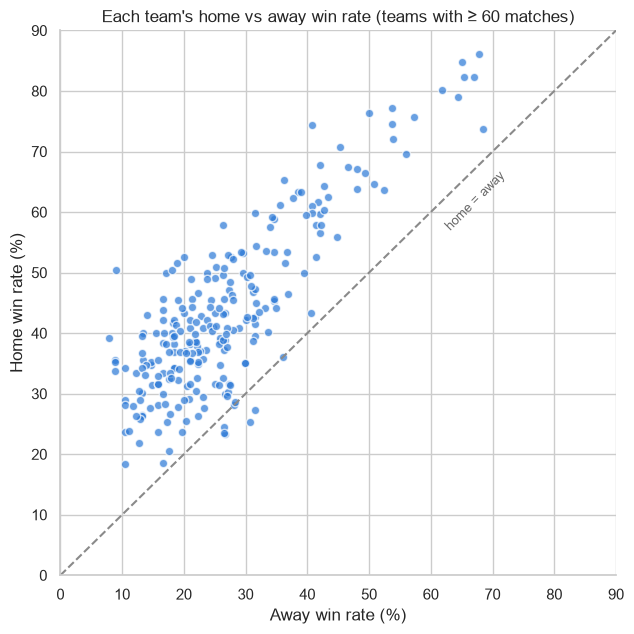

In [22]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(team_rates["away"], team_rates["home"], s=36, color=OUTCOME_COLORS["Home Win"], alpha=0.7,
           edgecolor="white", linewidth=1)
ax.plot([0, 90], [0, 90], color="#8a8a8a", linewidth=1.5, linestyle="--")
ax.text(62, 57, "home = away", color="#6b6b6b", fontsize=9, rotation=45)
ax.set_xlim(0, 90)
ax.set_ylim(0, 90)
ax.set_xlabel("Away win rate (%)")
ax.set_ylabel("Home win rate (%)")
ax.set_title(f"Each team's home vs away win rate (teams with ≥ {MIN_MATCHES} matches)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_08_team_home_vs_away_win_rate.png", dpi=150)
plt.show()

**Findings:**

- **97% of teams win more often at home than away**. Almost every point sits above the diagonal.
- A team's home and away win rates are **strongly correlated (r ≈ 0.83)**. Strong teams win everywhere, and the home
  edge comes on top of that. Typical team: about 43% home wins vs 27% away wins.
- **Why it matters:**
  - `Home_Win_Rate` (home team's record at home) and `Away_Win_Rate` (away team's record away) are both worth building.
    Together they encode both **team strength** and **venue effect**.
  - Rates measured on a team's *own* venue history also capture team-specific home advantage.
  - Because home and away rates of the *same* team are highly correlated, adding both rates for both teams would be
    largely redundant and collinear. That matters for Logistic Regression coefficients, but not for trees.
  - These rates must be **expanding means over strictly earlier matches** (guide §5.3). The full-history rates above are
    for EDA only, because they include the future.

## 10. Does recent form carry signal?

A rough, **leak-free** version of the planned `Home_Form_Last_5` / `Away_Form_Last_5`: the points from each team's
previous 5 matches, using `shift(1)` so the current match is never included. This is an EDA check only; Umair builds
the production feature.

In [23]:
g = team_matches.groupby("team_api_id")
team_matches["form5"] = g["points"].transform(lambda s: s.shift(1).rolling(5).sum())
team_matches["n_prior"] = g.cumcount()                        # matches this team played before this one
team_matches["rest_days"] = g["date"].diff().dt.days

# Leakage spot-check: the first 7 matches of one team, form must only use earlier rows
from src.db import load_teams
print(load_teams().set_index("team_api_id").loc[8455, "team_long_name"])
team_matches.loc[team_matches["team_api_id"] == 8455,
                 ["date", "venue", "goals_for", "goals_against", "points", "form5"]].head(7)

Chelsea


,date,venue,goals_for,goals_against,points,form5
11184,2008-08-17,home,4,0,3,NaN
11185,2008-08-24,away,1,0,3,NaN
11186,2008-08-31,home,1,1,1,NaN
11187,2008-09-13,away,3,1,3,NaN
11188,2008-09-21,home,1,1,1,NaN
11189,2008-09-27,away,2,0,3,11.0
11190,2008-10-05,home,2,0,3,11.0


Chelsea (8455): the 6th match's `form5` = 3+3+1+3+1 = **11**, the points of matches 1–5 only. Its own result (a win)
is not included, so the feature is leak-free. The 7th match is 3+1+3+1+3 = 11, the window sliding by one. The first 5
matches are `NaN` because there is not yet a full 5-match history.

In [24]:
def to_match_level(long, col):
    wide = long.pivot_table(index="id", columns="venue", values=col)
    return wide.rename(columns={"home": f"home_{col}", "away": f"away_{col}"})

feat = matches.set_index("id")[["target", "season"]].join(to_match_level(team_matches, "form5"))
feat["form_diff"] = feat["home_form5"] - feat["away_form5"]

# Form difference is an integer from -15 to +15; bins are (left, right]
bins = [-16, -6, -3, -1, 1, 3, 6, 16]
labels = ["≤ −6", "−5 to −3", "−2 to −1", "0 to +1", "+2 to +3", "+4 to +6", "≥ +7"]
feat["form_diff_bin"] = pd.cut(feat["form_diff"], bins=bins, labels=labels)

form_table = pd.crosstab(feat["form_diff_bin"], feat["target"], normalize="index")[OUTCOMES] * 100
form_table["matches"] = feat["form_diff_bin"].value_counts()
form_table.round(1)

target,Home Win,Draw,Away Win,matches
form_diff_bin,,,,
≤ −6,29.5,25.3,45.2,3351
−5 to −3,38.4,25.8,35.8,4687
−2 to −1,41.9,27.6,30.5,3911
0 to +1,46.6,27.9,25.5,4165
+2 to +3,51.9,25.1,22.9,3572
+4 to +6,57.1,22.5,20.3,3389
≥ +7,68.8,18.9,12.3,1886


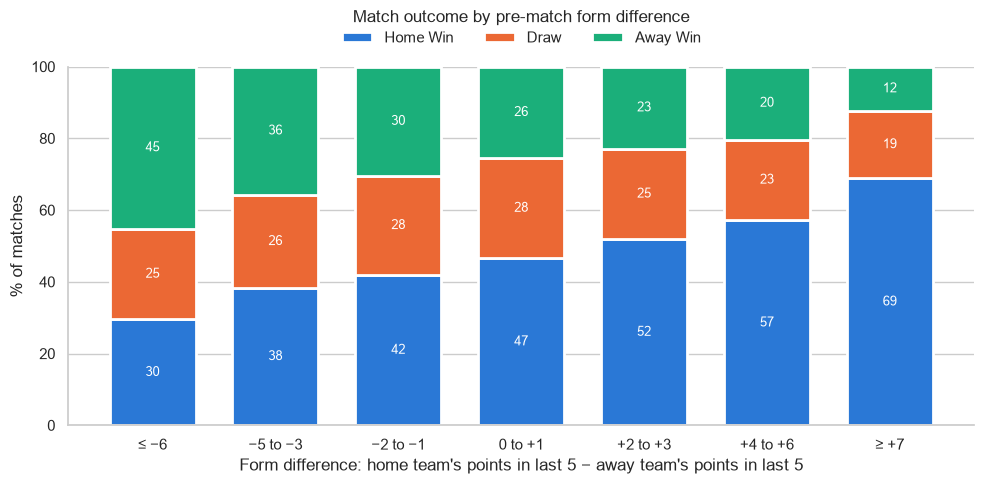

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
left = np.zeros(len(form_table))
x = np.arange(len(form_table))
for outcome in OUTCOMES:
    vals = form_table[outcome].values
    ax.bar(x, vals, bottom=left, color=OUTCOME_COLORS[outcome], label=outcome, width=0.7, edgecolor="white", linewidth=2)
    for xi, (b, v) in enumerate(zip(left, vals)):
        ax.text(xi, b + v / 2, f"{v:.0f}", ha="center", va="center", fontsize=9, color="white")
    left += vals
ax.set_xticks(x, form_table.index)
ax.set_ylim(0, 100)
ax.set_xlabel("Form difference: home team's points in last 5 − away team's points in last 5")
ax.set_ylabel("% of matches")
ax.set_title("Match outcome by pre-match form difference", pad=32)
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_09_outcome_by_form_difference.png", dpi=150)
plt.show()

**Findings:**

- **Form carries a strong, monotonic signal.** When the home team's last-5 form is **7+ points better**, it wins
  **68.8%** of matches. When it is **6+ points worse**, it wins only **29.5%**, and the away team wins 45.2%.
- Even when form is equal (0 to +1), the home team still wins **46.6%** vs 25.5% away. That is home advantage
  on its own.
- **Why it matters:** this is direct evidence for `Home_Form_Last_5` and `Away_Form_Last_5`, and a sign that a **form
  difference** feature could be even more useful for linear models. Even so, form explains only part of the outcome:
  the correlation between form difference and final goal difference is **weak (r = 0.27)**, see below. Football is
  noisy, so expect macro F1 well below 1.0, and treat a solid gain over the baseline as a success.

In [26]:
gd = matches.set_index("id")["home_team_goal"] - matches.set_index("id")["away_team_goal"]
print(f"Correlation between form difference and goal difference: {feat['form_diff'].corr(gd):.2f}")

Correlation between form difference and goal difference: 0.27


## 11. Draws — the hardest class

In [27]:
draws = matches[matches["target"] == "Draw"]
print(f"0-0 draws: {((matches['home_team_goal'] == 0) & (matches['away_team_goal'] == 0)).mean():.1%} of all matches")
print("Draw scorelines (% of draws):")
print((draws["home_team_goal"].value_counts(normalize=True).sort_index() * 100).round(1).rename(lambda g: f"{g}-{g}").to_string())

feat["abs_form_diff"] = feat["form_diff"].abs()
draw_by_gap = (feat.groupby(pd.cut(feat["abs_form_diff"], [-1, 1, 3, 6, 15],
                                   labels=["0–1 (even)", "2–3", "4–6", "7+ (mismatch)"]), observed=True)["target"]
               .apply(lambda s: (s == "Draw").mean() * 100).round(1))
draw_by_gap.rename("draw rate %").to_frame()

0-0 draws: 7.6% of all matches
Draw scorelines (% of draws):
home_team_goal
0-0    30.0
1-1    45.7
2-2    19.9
3-3     4.0
4-4     0.4
5-5     0.0
6-6     0.0


,draw rate %
abs_form_diff,
0–1 (even),27.5
2–3,25.9
4–6,24.5
7+ (mismatch),22.3


**Findings:**

- 0-0 accounts for **7.6%** of all matches. **1-1 is the most common draw (45.7% of draws)**, then 0-0 (30.0%) and 2-2 (19.9%).
- The draw rate rises only slightly when teams are evenly matched: **27.5%** when form is within 1 point vs **22.3%** for
  big mismatches. The draw rate barely changes across all form gaps.
- **Why it matters:** no single pre-match signal strongly separates draws. That is why draws are the hardest class
  (guide §5.7), and why the majority baseline and unweighted models will rarely predict "Draw". Recommend
  `class_weight="balanced"`, and report **Draw recall** explicitly. A "closeness" feature such as |form difference|
  is the most promising draw signal.

## 12. History length, cold start and rest days

In [28]:
per_team_season = team_matches.groupby(["team_api_id", "season"]).size()
print("Matches per team per season:")
print(per_team_season.describe().round(1).to_string())

first_season = team_matches.groupby("team_api_id")["season"].min()
print(f"\nTeams whose first match is after 2008/09 (promoted or newly added): {(first_season != '2008/2009').sum()} of {len(first_season)}")

feat = feat.join(to_match_level(team_matches, "n_prior"))
cold = (feat["home_n_prior"] < 5) | (feat["away_n_prior"] < 5)
print(f"Matches where either team has < 5 earlier matches (no full last-5 form): {cold.sum():,} ({cold.mean():.1%})")
cold.groupby(feat["season"]).sum().rename("cold-start matches").to_frame().T

Matches per team per season:
count    1481.0
mean       35.1
std         3.6
min         6.0
25%        34.0
50%        36.0
75%        38.0
max        38.0

Teams whose first match is after 2008/09 (promoted or newly added): 111 of 299
Matches where either team has < 5 earlier matches (no full last-5 form): 1,018 (3.9%)


season,2008/2009,2009/2010,2010/2011,2011/2012,2012/2013,2013/2014,2014/2015,2015/2016
cold-start matches,474,117,85,82,77,64,55,64


In [29]:
# Should "last 5" restart every season? Compare how many matches lose the feature.
team_matches["form5_season_reset"] = (team_matches.groupby(["team_api_id", "season"])["points"]
                                      .transform(lambda s: s.shift(1).rolling(5).sum()))
feat = feat.join(to_match_level(team_matches, "form5_season_reset"))
missing_rolling = feat[["home_form5", "away_form5"]].isna().any(axis=1).mean()
missing_reset = feat[["home_form5_season_reset", "away_form5_season_reset"]].isna().any(axis=1).mean()
print(f"Matches missing last-5 form — rolling across seasons: {missing_rolling:.1%}; reset each season: {missing_reset:.1%}")

Matches missing last-5 form — rolling across seasons: 3.9%; reset each season: 14.3%


In [30]:
rest = team_matches["rest_days"].dropna()
print(rest.describe().round(1).to_string())
print(f"\nGaps > 60 days (summer breaks, relegation and return): {(rest > 60).mean():.1%}; longest: {rest.max():,.0f} days")

count    51659.0
mean        10.7
std         31.1
min          2.0
25%          6.0
50%          7.0
75%          8.0
max       1877.0

Gaps > 60 days (summer breaks, relegation and return): 2.5%; longest: 1,877 days


**Findings:**

- Teams play **~34–38 league matches a season** (median 36), so a **5-match window** is about 13% of a season: recent
  enough to be "form", long enough to be less noisy than 1–2 games.
- **Cold start:** 1,018 matches (**3.9%**) have a team with fewer than 5 earlier matches, mostly in **2008/09 (474)**,
  where every team starts with no history. The rest are **promoted teams**: 111 of 299 teams first appear after 2008/09,
  and their earlier lower-division matches are not in the database.
- **Rolling across seasons loses 3.9% of matches; resetting every season loses 14.3%.** Recommend rolling across
  seasons, accepting that early-season form partly reflects the end of last season.
- **Rest days:** median 7 days, but 2.5% of gaps are over 60 days. These are summer breaks and, at the extreme
  (1,877 days), teams relegated out of the dataset and promoted back years later. A raw rest-days feature would be dominated by these gaps, so it should be **capped** (e.g. at 30 days)
  or turned into a "first match after a break" flag, if it is used at all.
- **Options for Umair** (decision log entry needed):
  1. Drop the 2008/09 season from training (it is the warm-up season for all history features) and impute the
     remaining cold-start rows.
  2. Keep all rows and impute missing form with a neutral value (e.g. league-average points), plus a `has_history` flag.
  3. Require `min_periods` < 5 so early matches use whatever history exists.

## 13. Correlation between candidate features

Rough leak-free versions of the six planned features (shift → rolling / expanding). This checks for redundancy before
the real features are built.

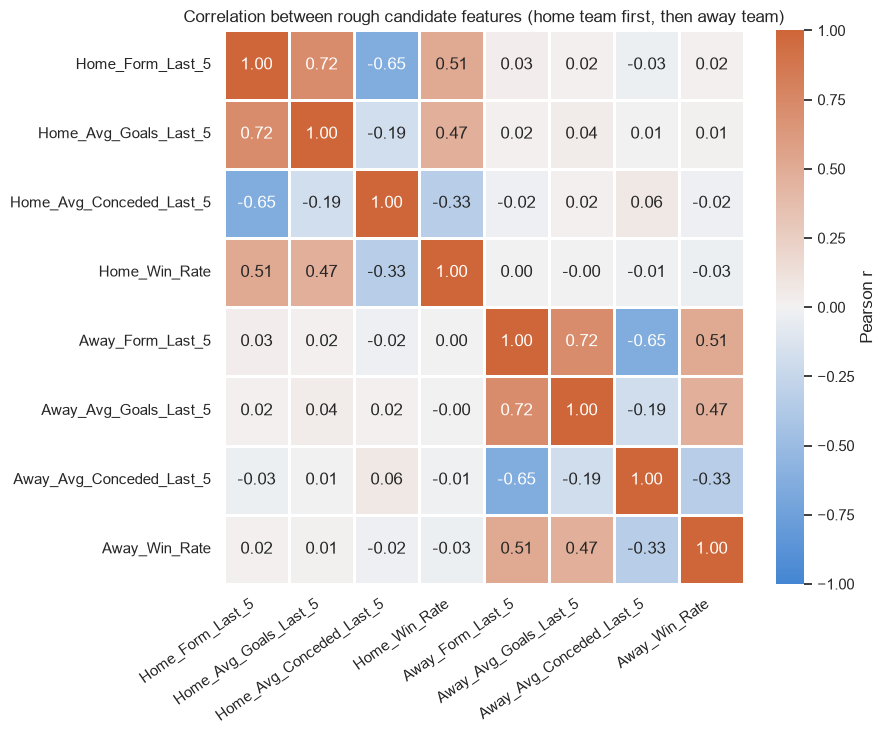

In [31]:
g = team_matches.groupby("team_api_id")
team_matches["avg_goals_for5"] = g["goals_for"].transform(lambda s: s.shift(1).rolling(5).mean())
team_matches["avg_goals_against5"] = g["goals_against"].transform(lambda s: s.shift(1).rolling(5).mean())
# Win rate at the same venue, from strictly earlier matches
team_matches["venue_win_rate"] = (team_matches.groupby(["team_api_id", "venue"])["win"]
                                  .transform(lambda s: s.shift(1).expanding().mean()))

cand = pd.concat([to_match_level(team_matches, c) for c in
                  ["form5", "avg_goals_for5", "avg_goals_against5", "venue_win_rate"]], axis=1)
cand = cand.rename(columns={
    "home_form5": "Home_Form_Last_5", "away_form5": "Away_Form_Last_5",
    "home_avg_goals_for5": "Home_Avg_Goals_Last_5", "away_avg_goals_for5": "Away_Avg_Goals_Last_5",
    "home_avg_goals_against5": "Home_Avg_Conceded_Last_5", "away_avg_goals_against5": "Away_Avg_Conceded_Last_5",
    "home_venue_win_rate": "Home_Win_Rate", "away_venue_win_rate": "Away_Win_Rate",
})
order = [f"{side}_{name}" for side in ("Home", "Away")
         for name in ("Form_Last_5", "Avg_Goals_Last_5", "Avg_Conceded_Last_5", "Win_Rate")]
corr = cand[order].corr()
corr.index.name = corr.columns.name = None

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, center=0, linewidths=1, linecolor="white",
            cmap=sns.diverging_palette(250, 25, s=80, l=55, as_cmap=True), cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation between rough candidate features (home team first, then away team)")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_10_candidate_feature_correlation.png", dpi=150)
plt.show()

**Findings:**

- The correlations are **within the same team**: last-5 form vs goals scored **r = 0.72**, vs goals conceded
  **r = −0.65**, vs venue win rate **r = 0.51**. They all partly measure the same underlying **team strength**.
- Home-team features and away-team features are essentially **uncorrelated (|r| ≤ 0.06)**, so the two sides add
  **independent information**, as expected.
- **Why it matters:** no pair is close to ±1, so no feature is redundant and all planned features can be kept,
  including goals conceded, which is not yet in the Initial Submission list. Moderate same-team correlation makes
  Logistic Regression coefficients harder to interpret one by one. Use Random Forest importance (Phase 8) for
  "which factor matters most".

## 14. Pattern summary (Part B)

| # | Finding | Why it matters for modelling | Action / owner |
|---|---|---|---|
| B1 | Home teams score 1.54 vs away 1.16 goals per match | Venue shifts goal distributions; read goal features with venue | Umair |
| B2 | Home advantage in every league, +7.8 pts (Scotland) to +20.9 pts (Spain) | Not uniform; team-level home/away rates capture it | Umair |
| B3 | 97% of teams win more at home; team home and away win rates correlate at r ≈ 0.83 | Build `Home_Win_Rate` / `Away_Win_Rate`; expect collinearity in LR | Umair, Yusuf |
| B4 | Outcome varies strongly with last-5 form difference (home win 29.5% → 68.8%) | Strong evidence for `*_Form_Last_5`; consider a form-difference feature | Umair |
| B5 | Draw rate barely varies with form (22–28%); 1-1 is 46% of draws | Draws hard to predict; use `class_weight="balanced"`, report Draw recall | Yusuf |
| B6 | 3.9% of matches lack a full last-5 history (474 in 2008/09); 111 teams are promoted mid-dataset | Cold-start handling must be decided and logged | Umair |
| B7 | Season-reset form loses 14.3% of matches vs 3.9% rolling across seasons | Roll across seasons | Umair |
| B8 | Rest-day gaps up to 1,877 days | Cap or flag if rest days are used | Umair |
| B9 | Same-team candidate features correlate moderately (|r| 0.5–0.72); home vs away features do not (|r| ≤ 0.06) | No redundant feature; add goals conceded; interpret LR coefficients cautiously | Umair, Yusuf |